House price prediction - regression dataset

In [184]:
import pandas

In [185]:
data = pandas.read_csv("/content/sample_data/california_housing_test.csv")

In [186]:
data.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0


In [187]:
data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


## Data split

In [188]:
y = data[['median_house_value']]

In [189]:
X = data.iloc[:,0:7]

In [190]:
from sklearn.model_selection import train_test_split

In [191]:
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state=0)

In [192]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

## SVR

In [193]:
from sklearn.svm import SVR

In [194]:
model = SVR()

In [195]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [196]:
model.score(X_test,y_test)

0.5376861190536002

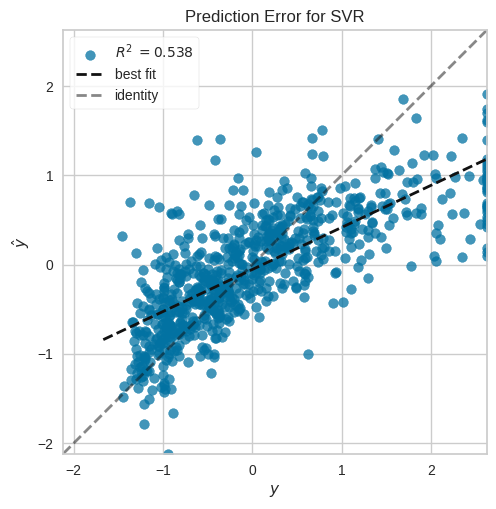

<Axes: title={'center': 'Prediction Error for SVR'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [197]:
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(model)
visualizer.fit(X_train, y_train)
visualizer.score(X_test,y_test)
visualizer.show()